In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
data_path_hsa = '../../../data/raw/HSA'  # specify your path here
folder = Path(data_path_hsa)  # change to your folder path
print(f'Reading CSV files from {folder}')
csv_files = sorted(folder.glob('*.csv'))

if not csv_files:
    print(f'No CSV files found in {folder}')
else:
    # read each CSV into a dict of DataFrames keyed by filename (without suffix)
    dfs = {p.stem: pd.read_csv(p) for p in csv_files}

    # optional: concatenate all into a single DataFrame
    combined = pd.concat(dfs.values(), ignore_index=True)

    print(f'Read {len(dfs)} files. Combined shape: {combined.shape}')

Reading CSV files from ..\..\..\data\raw\HSA
Read 57 files. Combined shape: (251892, 5)


In [3]:
def make_continuous(x, threshold=None):
    """
    Unwraps a resetting position signal.
    x: array-like
    threshold: negative jump threshold (auto if None)
    """
    x = np.array(x)
    dx = np.diff(x)

    # Auto threshold: any large negative jump
    if threshold is None:
        threshold = -0.5 * np.max(x)  

    offset = 0
    x_cont = np.zeros_like(x)

    for i in range(len(x)):
        if i > 0 and dx[i-1] < threshold:
            # Counter reset detected
            offset += x[i-1]
        x_cont[i] = x[i] + offset

    return x_cont


In [4]:
# rename columns in all loaded DataFrames and save renamed CSVs to a new folder
prepro_path = '../../../data/preprocessed/HSA' 
#prepro_path.mkdir(parents=True, exist_ok=True)

# rename columns for clarity
col_map = {
    '+/Nck/!SD/nckServoDataActCurr32 [u1; 4]': 'iqAx4',
    '+/Channel/!RP/rpa [u1; 11]': 'rpa',
    '+/Nck/!SD/nckServoDataActPower32 [u1; 4]': 'powerAx4',
    '+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]': 'velAx4'
}


for stem, df in list(dfs.items()):
    # apply the column mapping (rename ignores keys not present)
    df_renamed = df.rename(columns=col_map)
    # update the in-memory dict to hold renamed DataFrame
    dfs[stem] = df_renamed
    # save with the same filename (stem) into the new folder
    df_renamed = df_renamed.drop(columns="rpa")
    out_file = f'{prepro_path}/{stem}.csv'
    df_renamed.to_csv(out_file, index=False)
    print(f"Saved: {out_file}")

Saved: ../../../data/preprocessed/HSA/Trace_1028_161651.csv
Saved: ../../../data/preprocessed/HSA/Trace_1028_162435.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_110641.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_122711.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123420.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123530.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123701.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123727.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123752.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123912.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_123937.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_124002.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_124027.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_124052.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_124117.csv
Saved: ../../../data/preprocessed/HSA/Trace_1030_124154.csv
Saved: ../../../data/preprocessed/HSA/Tr

In [5]:
df_renamed.isnull().sum()

time        0
iqAx4       0
powerAx4    0
velAx4      0
dtype: int64

In [6]:
import sys
sys.path.append("../../py")   # or an absolute path

from machine_tool_parser import MachineToolParser


In [8]:
MDACHSFile = '../../../data/cnc_config_data/MDACHSX4.TEA'
MDANTRXFile ='../../../data/cnc_config_data/MDANTRX4.TEA'
parser = MachineToolParser(
    MDACHSFile,
    MDANTRXFile,
    drive="DR4"
)

# Convert raw CSV signals → physics units
file_path = '../../../data/preprocessed/HSA/Trace_1030_124723.csv'
df_phys = parser.process_csv(file_path)
print(df_phys.head())
# The dataframe must contain time column (if not, add one)
df_phys["time"] = df_phys.index * 0.001   # example: 1 kHz logging

# Identify dynamics
J, B, sid = parser.identify_spindle_dynamics(df_phys)
print(" ")
print("Estimated inertia J =", J, "kg·m²")
print("Estimated damping B =", B, "Nm·s/rad")


    time     iqAx4  powerAx4        velAx4           rpm  omega_rad_s  \
0  0.000   0.24353   0.19736  179993.51563  17999.351563  1884.887688   
1  0.008   1.70471   1.05806  180048.60938  18004.860938  1885.464628   
2  0.016  -0.74084  -0.34538  180031.46875  18003.146875  1885.285132   
3  0.024  19.52600  11.31526  180491.57813  18049.157813  1890.103386   
4  0.032  34.39929  19.57145  182981.95313  18298.195313  1916.182532   

      I_pct       I_A     P_pct      P_kW        P_W      T_Nm  
0  0.024353  0.014368  0.019736  0.002368    2.36832  0.001257  
1  0.170471  0.100578  0.105806  0.012697   12.69672  0.006734  
2 -0.074084 -0.043710 -0.034538 -0.004145   -4.14456 -0.002199  
3  1.952600  1.152034  1.131526  0.135783  135.78312  0.071844  
4  3.439929  2.029558  1.957145  0.234857  234.85740  0.122574  
 
Estimated inertia J = 4.48408183143698e-06 kg·m²
Estimated damping B = 7.620999013162226e-07 Nm·s/rad


In [9]:
# Estimate J and B for all preprocessed files and save to dataframe
results = []

for stem in dfs.keys():
    try:
        file_path = f'{prepro_path}/{stem}.csv'
        df_phys_temp = parser.process_csv(file_path)
        df_phys_temp["time"] = df_phys_temp.index * 0.001
        
        J_temp, B_temp, sid_temp = parser.identify_spindle_dynamics(df_phys_temp)
        
        results.append({
            'file': stem,
            'J_kg_m2': J_temp,
            'B_Nm_s_rad': B_temp
        })
        print(f"Processed {stem}: J={J_temp:.6e}, B={B_temp:.6e}")
    except Exception as e:
        print(f"Error processing {stem}: {e}")

# Create results dataframe
results_df = pd.DataFrame(results)
print(f"\nEstimated dynamics for {len(results_df)} files:")
print(results_df)

Processed Trace_1028_161651: J=4.261731e-06, B=1.783799e-06
Processed Trace_1028_162435: J=3.679920e-06, B=3.422590e-07
Processed Trace_1030_110641: J=3.833173e-06, B=1.291505e-05
Processed Trace_1030_122711: J=4.505052e-06, B=1.339978e-05
Processed Trace_1030_123420: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_123530: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_123701: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_123727: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_123752: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_123912: J=1.486735e-06, B=1.594162e-07
Processed Trace_1030_123937: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_124002: J=0.000000e+00, B=0.000000e+00
Processed Trace_1030_124027: J=6.122808e-07, B=1.501777e-07
Processed Trace_1030_124052: J=6.940204e-07, B=7.968238e-08
Processed Trace_1030_124117: J=4.914226e-07, B=9.121001e-08
Processed Trace_1030_124154: J=3.901349e-06, B=4.512204e-08
Processed Trace_1030_124219: J=3.769187e

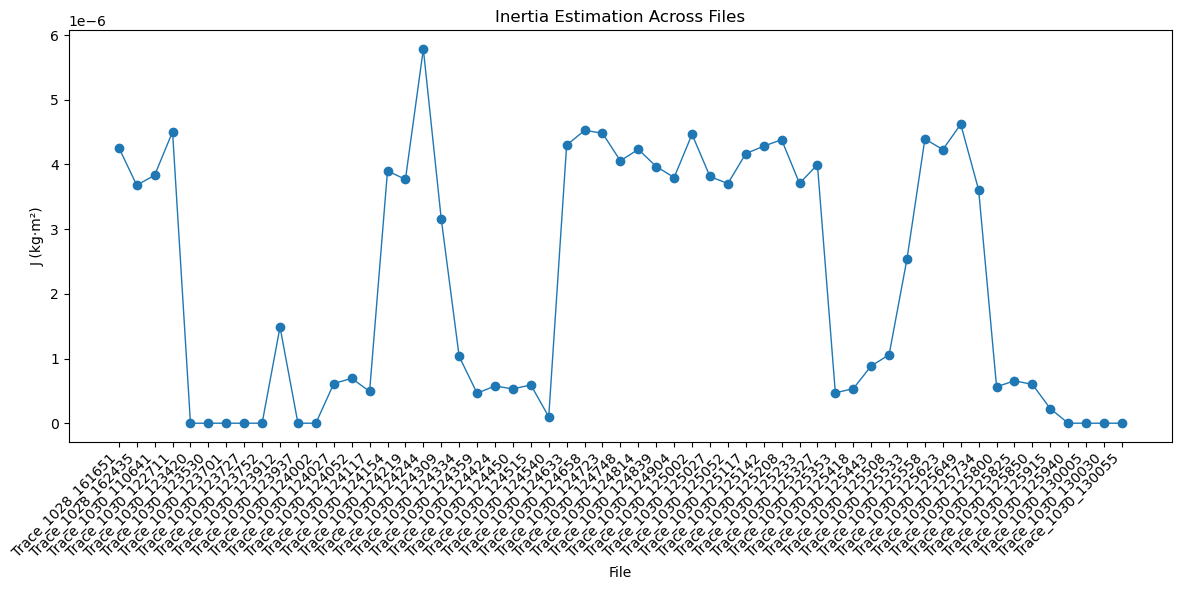

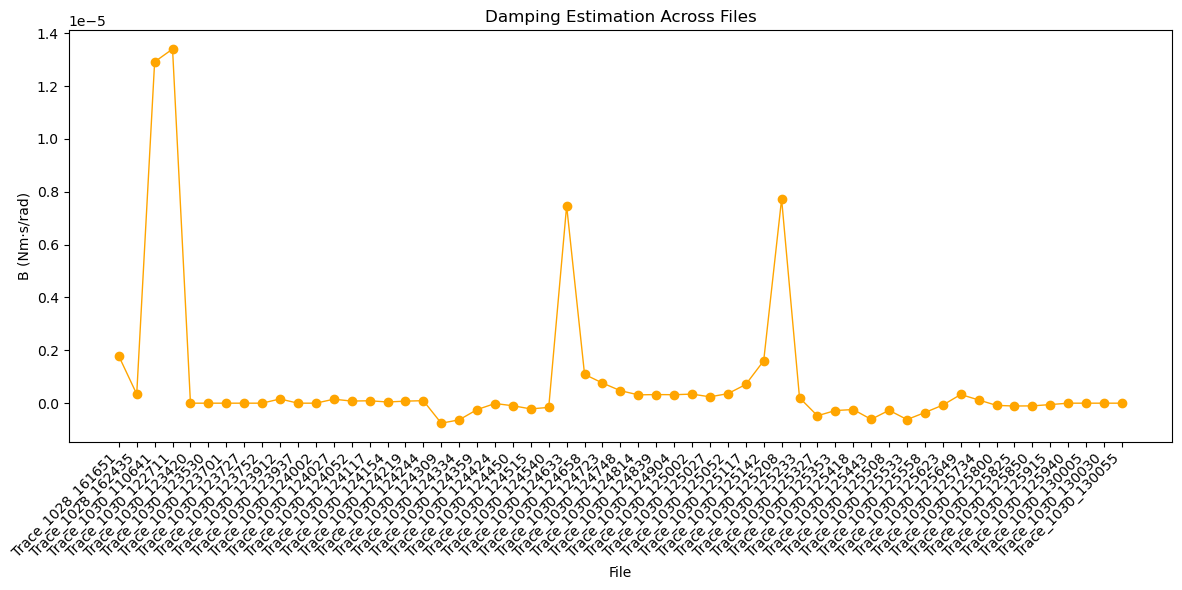

In [14]:
# --- Plot J ---
plt.figure(figsize=(12, 6))
plt.plot(
    results_df['file'],
    results_df['J_kg_m2'],
    marker='o',
    linestyle='-',
    linewidth=1
)
plt.xlabel('File')
plt.ylabel('J (kg·m²)')
plt.title('Inertia Estimation Across Files')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot B ---
plt.figure(figsize=(12, 6))
plt.plot(
    results_df['file'],
    results_df['B_Nm_s_rad'],
    marker='o',
    linestyle='-',
    linewidth=1,
    color='orange'   # optional: remove if you want default color cycle
)
plt.xlabel('File')
plt.ylabel('B (Nm·s/rad)')
plt.title('Damping Estimation Across Files')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\thmru\anaconda3\envs\ufactory\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


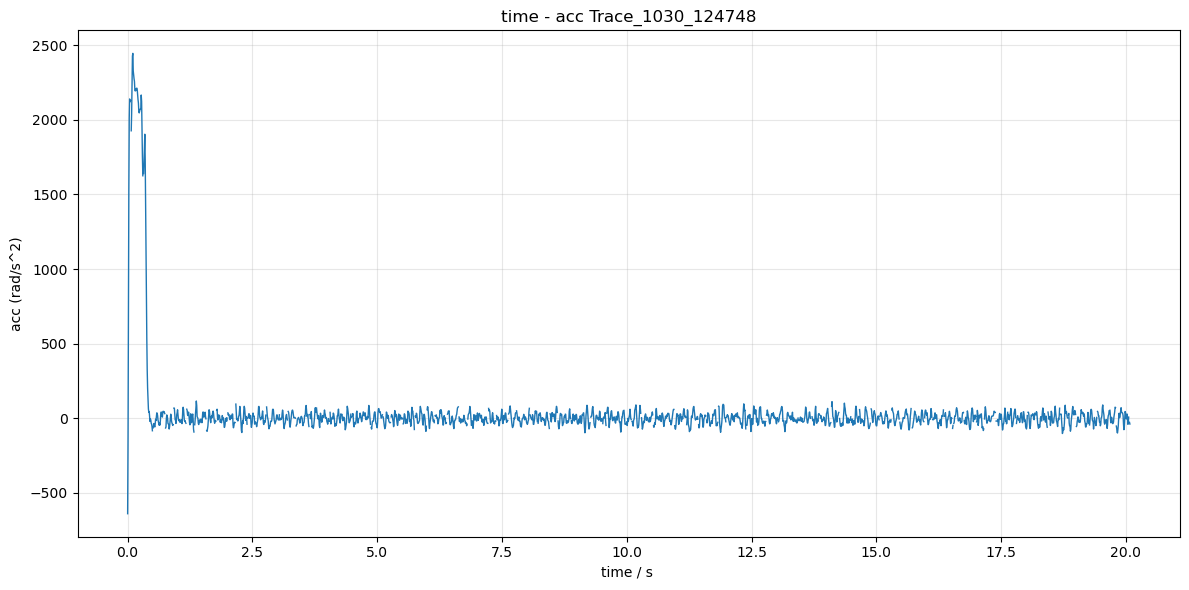

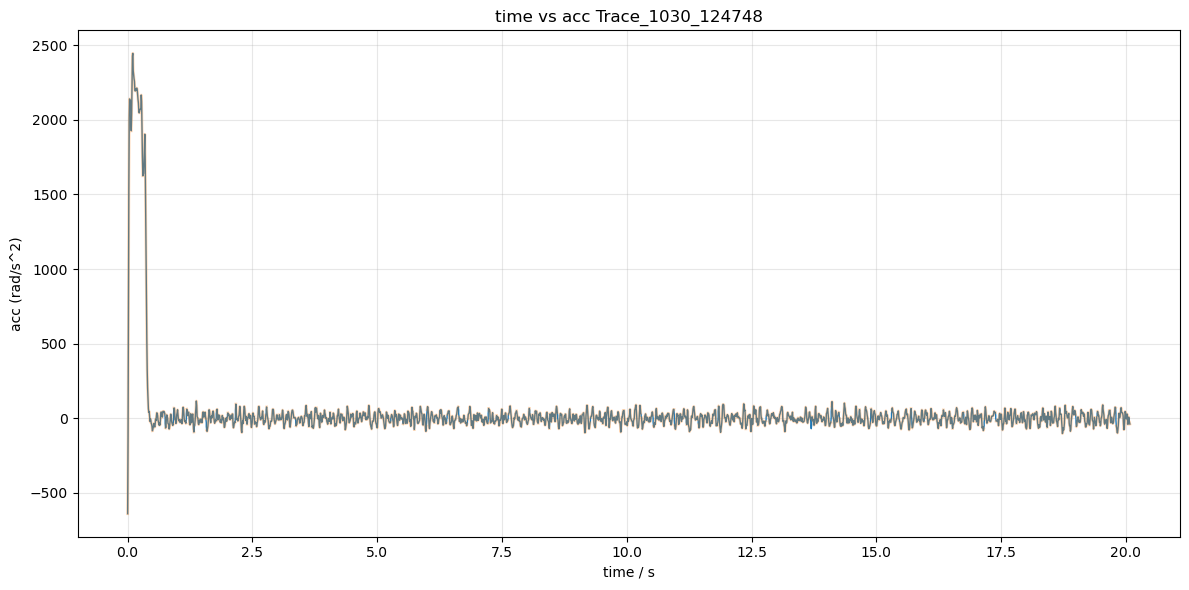

In [62]:
from scipy.signal import savgol_filter

# Filter the results for the specific file
file_name = 'Trace_1030_124748'
file_path = f'{prepro_path}/{file_name}.csv'

# Read the file
df_plot = parser.process_csv(file_path)
omega = df_plot['omega_rad_s']
time = df_plot['time']
omega_s = savgol_filter(omega, 11, 3)

acc = np.gradient(omega_s, time)
acc_clean = pd.Series(acc).replace([np.inf, -np.inf], np.nan).interpolate().values
acc_s = savgol_filter(acc_clean, 11, 3)

# Plot omega_rad_s over time
#  iqAx4  powerAx4        velAx4           rpm  omega_rad_s
plt.figure(figsize=(12, 6))
plt.plot(df_plot['time'], acc, linewidth=1)
plt.xlabel('time / s ')
plt.ylabel('acc (rad/s^2)')
plt.title(f'time - acc {file_name}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_plot['time'], acc_clean, linewidth=1)
plt.plot(df_plot['time'], acc, alpha=0.3, linewidth=2)
plt.xlabel('time / s')
plt.ylabel('acc (rad/s^2)')
plt.title(f'time vs acc {file_name}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
A

array([[-638.66535688, 2640.10198958],
       [-120.94245425, 2634.99266672],
       [ 806.17516516, 2638.16691031],
       ...,
       [          nan, 3392.13670673],
       [ -26.44010764, 3392.01891989],
       [ -38.15686029, 3391.71366501]])

In [31]:
print(np.diff(df_plot['time']).size)
print(np.diff(df_plot['omega_rad_s']).size)
print((df_plot['omega_rad_s']).size)
#df_plot['Omega_rad_s'].size    

2613
2613
2614


In [15]:
df_plot.head(20)

,time,iqAx4,powerAx4,velAx4
0,0.000,0.00256,0.0,3.42761
1,0.008,-0.00256,0.0,-0.26378
2,0.016,0.00000,0.0,1.05474
3,0.024,1.56885,0.0,70.66384
4,0.032,3.83752,0.0,542.10907
5,0.040,0.65112,0.0,750.14630
6,0.048,0.25891,0.0,747.24585
7,0.056,0.33069,0.0,735.64423
8,0.064,0.44092,0.0,731.95300
9,0.072,0.57166,0.0,723.51532
